In [1]:
import pandas as pd
import numpy as np
import re
from pathlib import Path

pd.set_option("display.max_columns", None)
df_market = pd.read_csv( "../data/processed/market_dataset_tagged.csv")
df = df_market.copy()

<Axes: xlabel='research_group'>

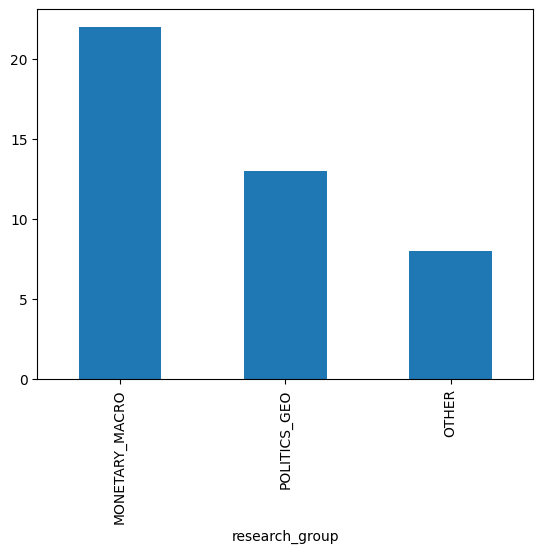

In [2]:
(
    df["research_group"]
    .value_counts()
    .plot(kind="bar")
)

In [3]:
(
    df.groupby("research_group")["outcome"]
      .mean()
      .sort_values()
)

research_group
POLITICS_GEO      0.230769
OTHER             0.250000
MONETARY_MACRO    0.409091
Name: outcome, dtype: float64

In [4]:
df.groupby(
    "research_group"
)["market_duration_days"].agg([
    "count",
    "mean",
    "median",
    "std"
])

,count,mean,median,std
research_group,,,,
MONETARY_MACRO,22,123.318182,99.5,104.133790
OTHER,8,48.375000,14.0,74.664846
POLITICS_GEO,13,83.615385,34.0,106.068012


<Axes: xlabel='research_group', ylabel='market_duration_days'>

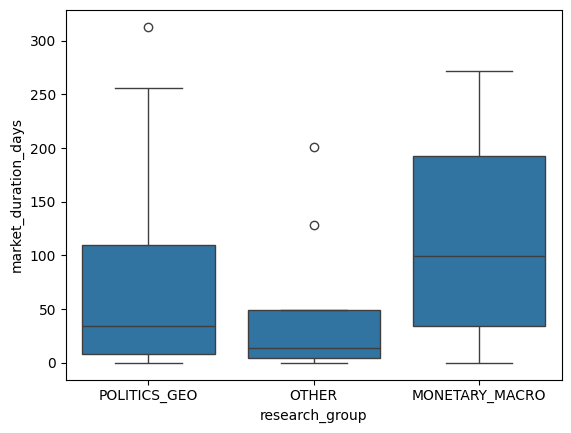

In [5]:
import seaborn as sns

sns.boxplot(
    data=df,
    x="research_group",
    y="market_duration_days"
)

<Axes: xlabel='mean_probability', ylabel='Density'>

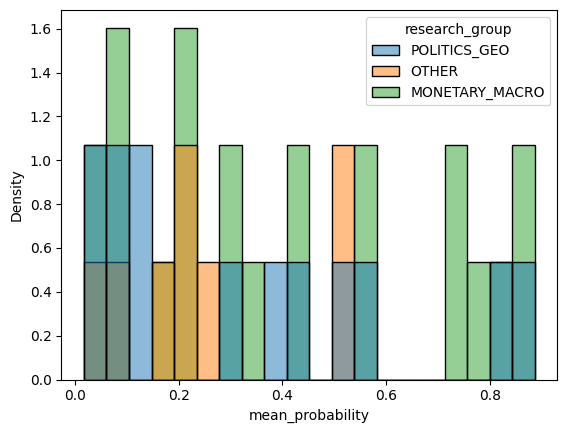

In [6]:
sns.histplot(
    data=df,
    x="mean_probability",
    hue="research_group",
    bins=20,
    stat="density"
)

<Axes: xlabel='research_group', ylabel='mean_probability'>

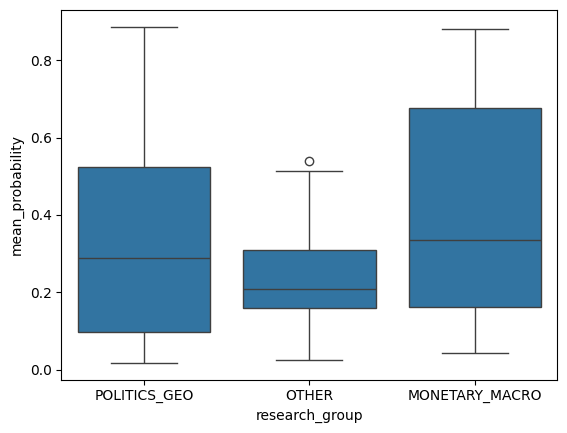

In [7]:
sns.boxplot(
    data=df,
    x="research_group",
    y="mean_probability"
)

<Axes: xlabel='research_group', ylabel='final_probability'>

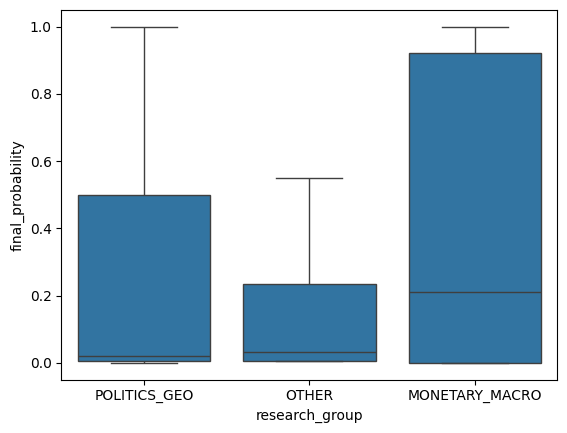

In [8]:
sns.boxplot(
    data=df,
    x="research_group",
    y="final_probability"
)

In [10]:
df.groupby(
    "research_group"
)["liquidity"].agg([
    "mean",
    "median"
])

,mean,median
research_group,,
MONETARY_MACRO,3.900500,0.0
OTHER,275.000000,0.0
POLITICS_GEO,446.104277,0.0


<Axes: xlabel='research_group', ylabel='liquidity'>

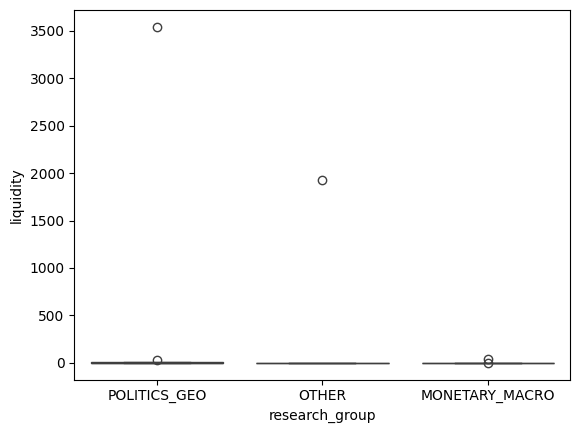

In [11]:
sns.boxplot(
    data=df,
    x="research_group",
    y="liquidity"
)

<Axes: xlabel='research_group', ylabel='volume'>

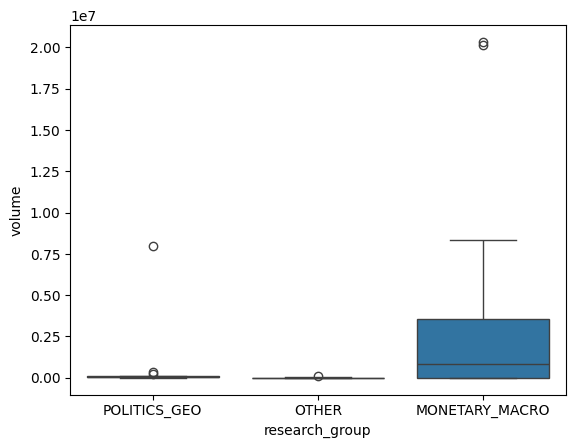

In [12]:
sns.boxplot(
    data=df,
    x="research_group",
    y="volume"
)

In [13]:
from scipy.stats import mannwhitneyu

macro = df.loc[
    df["research_group"]=="MONETARY_MACRO",
    "abs_surprise"
]

politics = df.loc[
    df["research_group"]=="POLITICS_GEO",
    "abs_surprise"
]

mannwhitneyu(
    macro,
    politics,
    alternative="two-sided"
)

MannwhitneyuResult(statistic=np.float64(129.0), pvalue=np.float64(0.6426624795861064))

In [17]:
df["surprise"] = (
    df["outcome"]
    - df["final_probability"]
)
df["abs_surprise"] = (
    df["outcome"]
    - df["final_probability"]
).abs()

df.groupby(
    "research_group"
)["abs_surprise"].agg([
    "mean",
    "median",
    "std"
])



,mean,median,std
research_group,,,
MONETARY_MACRO,0.100614,0.00725,0.184687
OTHER,0.191687,0.03250,0.280774
POLITICS_GEO,0.099038,0.00700,0.177008


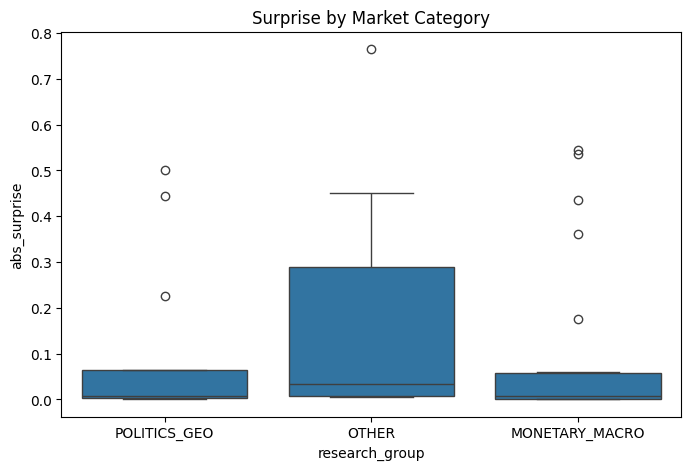

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="research_group",
    y="abs_surprise"
)

plt.title("Surprise by Market Category")
plt.show()  